# **71. 괄호 회전하기(250224)**(검색 도움)

In [ ]:
# 문제 설명
# 다음 규칙을 지키는 문자열을 올바른 괄호 문자열이라고 정의합니다.

# (), [], {} 는 모두 올바른 괄호 문자열입니다.
# 만약 A가 올바른 괄호 문자열이라면, (A), [A], {A} 도 올바른 괄호 문자열입니다.
# 예를 들어, [] 가 올바른 괄호 문자열이므로, ([]) 도 올바른 괄호 문자열입니다.
# 만약 A, B가 올바른 괄호 문자열이라면, AB 도 올바른 괄호 문자열입니다.
# 예를 들어, {} 와 ([]) 가 올바른 괄호 문자열이므로, {}([]) 도 올바른 괄호 문자열입니다.
# 대괄호, 중괄호, 그리고 소괄호로 이루어진 문자열 s가 매개변수로 주어집니다.
# 이 s를 왼쪽으로 x (0 ≤ x < (s의 길이)) 칸만큼 회전시켰을 때 s가 올바른 괄호 문자열이 되게 하는 x의 개수를 return 하도록 solution 함수를 완성해주세요.

# 제한사항
# s의 길이는 1 이상 1,000 이하입니다.
# 입출력 예
# s	result
# "[](){}"	3
# "}]()[{"	2
# "[)(]"	0
# "}}}"	0
# 입출력 예 설명
# 입출력 예 #1

# 다음 표는 "[](){}" 를 회전시킨 모습을 나타낸 것입니다.
# x	s를 왼쪽으로 x칸만큼 회전	올바른 괄호 문자열?
# 0	"[](){}"	O
# 1	"](){}["	X
# 2	"(){}[]"	O
# 3	"){}[]("	X
# 4	"{}[]()"	O
# 5	"}[](){"	X
# 올바른 괄호 문자열이 되는 x가 3개이므로, 3을 return 해야 합니다.
# 입출력 예 #2

# 다음 표는 "}]()[{" 를 회전시킨 모습을 나타낸 것입니다.
# x	s를 왼쪽으로 x칸만큼 회전	올바른 괄호 문자열?
# 0	"}]()[{"	X
# 1	"]()[{}"	X
# 2	"()[{}]"	O
# 3	")[{}]("	X
# 4	"[{}]()"	O
# 5	"{}]()["	X
# 올바른 괄호 문자열이 되는 x가 2개이므로, 2를 return 해야 합니다.
# 입출력 예 #3

# s를 어떻게 회전하더라도 올바른 괄호 문자열을 만들 수 없으므로, 0을 return 해야 합니다.
# 입출력 예 #4

# s를 어떻게 회전하더라도 올바른 괄호 문자열을 만들 수 없으므로, 0을 return 해야 합니다.

1) 내가 쓴 코드(테스트 완성도 98%)

In [ ]:
def solution(s):
    c1 = 0
    c2 = 0
    c3 = 0
    answer = 0
    rot = s[:]
    for _ in range(len(s)):
      for i in rot:
        if i == '[':
          c1 += 1
        elif i == '{':
          c2 += 1
        elif i == '(':
          c3 += 1
        elif i == ']':
          c1 -= 1
        elif i == '}':
          c2 -= 1
        elif i == ')':
          c3 -= 1
        if c1 < 0 or c2 < 0 or c3 < 0:
          break
      if c1 == 0 and c2 == 0 and c3 == 0:
        answer += 1
      rot += rot[0]
      rot = rot[1:]
      c1 = 0
      c2 = 0
      c3 = 0
    return answer

In [ ]:
s = "[](){}"

In [ ]:
solution(s)

3

2) gpt 개선 코드

In [ ]:
def solution(s):
    def is_valid(string):
        stack = []
        bracket_map = {')': '(', ']': '[', '}': '{'}
        for char in string:
            if char in "({[":
                stack.append(char)
            elif char in ")}]":
                if not stack or stack[-1] != bracket_map[char]:
                    return False
                stack.pop()
        return not stack  # 스택이 비어있으면 올바른 괄호 문자열

    answer = 0
    for x in range(len(s)):
        if is_valid(s):  # 현재 회전된 문자열이 올바른지 확인
            answer += 1
        s = s[1:] + s[0]  # 왼쪽으로 한 칸 회전
    return answer

3) gpt 제안 코드

In [ ]:
from collections import deque  # deque를 사용하여 O(1)로 문자열 회전

# 올바른 괄호 문자열인지 확인하는 함수
def is_valid(string):
    stack = []  # 스택을 활용하여 괄호 유효성 검사
    bracket_map = {')': '(', ']': '[', '}': '{'}  # 닫는 괄호와 여는 괄호 매핑

    for char in string:
        if char in "({[":  # 여는 괄호이면 스택에 추가
            stack.append(char)
        elif char in ")}]":  # 닫는 괄호이면 스택 검사
            if not stack or stack[-1] != bracket_map[char]:  # 스택이 비었거나 짝이 안 맞으면 False
                return False
            stack.pop()  # 짝이 맞으면 스택에서 제거

    return not stack  # 스택이 비어 있으면 올바른 괄호 문자열 (True), 남아 있으면 (False)

# 문자열을 회전하며 올바른 괄호 문자열 개수 구하기
def solution(s):
    answer = 0
    dq = deque(s)  # deque 사용 (O(1) 연산)

    for _ in range(len(s)):  # s를 한 칸씩 회전시키면서 검사
        if is_valid(dq):  # 현재 상태에서 올바른 괄호 문자열인지 확인
            answer += 1
        dq.append(dq.popleft())  # O(1) 연산으로 왼쪽으로 한 칸 회전

    return answer

4) 다른 사람의 코드

In [ ]:
# 올바른 괄호 문자열인지 확인하는 함수
def is_valid(s):
    stack = []  # 괄호를 저장할 스택
    for ch in s:
        if not stack:  # 스택이 비어 있으면 현재 괄호 추가
            stack.append(ch)
        elif stack[-1] == '(':  # 스택의 마지막 값이 '('이면
            if ch == ')':  # 닫는 괄호 ')'가 나오면 스택에서 '(' 제거
                stack.pop()
            else:  # 그 외의 경우 스택에 추가
                stack.append(ch)
        elif stack[-1] == '{':  # 중괄호 '{' 처리
            if ch == '}':  # '}'가 나오면 스택에서 '{' 제거
                stack.pop()
            else:
                stack.append(ch)
        elif stack[-1] == '[':  # 대괄호 '[' 처리
            if ch == ']':  # ']'가 나오면 스택에서 '[' 제거
                stack.pop()
            else:
                stack.append(ch)

    return False if stack else True  # 스택이 비어 있으면 올바른 문자열 (True), 아니면 (False)

# s를 회전시키면서 올바른 괄호 문자열의 개수를 계산하는 함수
def solution(s):
    answer = 0
    for i in range(len(s)):  # 문자열을 회전시키면서 검사
        answer += is_valid(s[i:] + s[:i])  # s를 i칸 왼쪽으로 회전한 결과를 검사
    return answer

📌 코드 분석

 - is_valid(s): 스택을 사용하여 올바른 괄호 문자열을 판별
 1. 여는 괄호 (, {, [는 스택에 추가
 2. 닫는 괄호 ), }, ]가 나올 때, 스택의 마지막 값과 짝이 맞으면 pop
 3. 스택이 비어 있으면 True, 남아 있으면 False
 - solution(s): 문자열을 회전시키며 is_valid로 검사
 1. s[i:] + s[:i]를 통해 왼쪽으로 i칸 회전한 문자열을 검사
 2. is_valid()가 True이면 answer 증가
 3. 총 O(N²)의 시간 복잡도 (모든 회전마다 is_valid 실행)

# **72. 할인 행사(250225)**

In [ ]:
# 문제 설명
# XYZ 마트는 일정한 금액을 지불하면 10일 동안 회원 자격을 부여합니다.
# XYZ 마트에서는 회원을 대상으로 매일 한 가지 제품을 할인하는 행사를 합니다.
# 할인하는 제품은 하루에 하나씩만 구매할 수 있습니다.
# 알뜰한 정현이는 자신이 원하는 제품과 수량이 할인하는 날짜와 10일 연속으로 일치할 경우에 맞춰서 회원가입을 하려 합니다.

# 예를 들어, 정현이가 원하는 제품이 바나나 3개, 사과 2개, 쌀 2개, 돼지고기 2개, 냄비 1개이며,
# XYZ 마트에서 14일간 회원을 대상으로 할인하는 제품이
# 날짜 순서대로 치킨, 사과, 사과, 바나나, 쌀, 사과, 돼지고기, 바나나, 돼지고기, 쌀, 냄비, 바나나, 사과, 바나나인 경우에 대해 알아봅시다.
# 첫째 날부터 열흘 간에는 냄비가 할인하지 않기 때문에 첫째 날에는 회원가입을 하지 않습니다.
# 둘째 날부터 열흘 간에는 바나나를 원하는 만큼 할인구매할 수 없기 때문에 둘째 날에도 회원가입을 하지 않습니다.
# 셋째 날, 넷째 날, 다섯째 날부터 각각 열흘은 원하는 제품과 수량이 일치하기 때문에 셋 중 하루에 회원가입을 하려 합니다.

# 정현이가 원하는 제품을 나타내는 문자열 배열 want와 정현이가 원하는 제품의 수량을 나타내는
# 정수 배열 number, XYZ 마트에서 할인하는 제품을 나타내는 문자열 배열 discount가 주어졌을 때,
# 회원등록시 정현이가 원하는 제품을 모두 할인 받을 수 있는 회원등록 날짜의 총 일수를 return 하는 solution 함수를 완성하시오.
# 가능한 날이 없으면 0을 return 합니다.

# 제한사항
# 1 ≤ want의 길이 = number의 길이 ≤ 10
# 1 ≤ number의 원소 ≤ 10
# number[i]는 want[i]의 수량을 의미하며, number의 원소의 합은 10입니다.
# 10 ≤ discount의 길이 ≤ 100,000
# want와 discount의 원소들은 알파벳 소문자로 이루어진 문자열입니다.
# 1 ≤ want의 원소의 길이, discount의 원소의 길이 ≤ 12

# 입출력 예
# want	number	discount	result
# ["banana", "apple", "rice", "pork", "pot"]	[3, 2, 2, 2, 1]	["chicken", "apple", "apple", "banana", "rice", "apple", "pork", "banana", "pork", "rice", "pot", "banana", "apple", "banana"]	3
# ["apple"]	[10]	["banana", "banana", "banana", "banana", "banana", "banana", "banana", "banana", "banana", "banana"]	0

# 입출력 예 설명

# 입출력 예 #1
# 문제 예시와 같습니다.

# 입출력 예 #2
# 사과가 할인하는 날이 없으므로 0을 return 합니다.

1) 내 코드

In [ ]:
def solution(want, number, discount):
    answer = 0
    buy = dict(zip(want, number))
    while len(discount) >= 10:
      count = 0
      for i in want:
        if i in discount[:10] and buy[i] == discount[:10].count(i):
          count += 1
      if count == len(want):
        answer += 1
      discount.pop(0)
    return answer

In [ ]:
want = ["banana", "apple", "rice", "pork", "pot"]

In [ ]:
number = [3, 2, 2, 2, 1]

In [ ]:
discount = ["chicken", "apple", "apple", "banana", "rice", "apple", "pork", "banana", "pork", "rice", "pot", "banana", "apple", "banana"]

In [ ]:
solution(want, number, discount)

3

2) gpt 개선코드

In [ ]:
# 1. 사용자의 기존 코드 개선 버전
def solution_improved(want, number, discount):
    answer = 0
    buy = dict(zip(want, number))  # 원하는 상품과 개수를 딕셔너리로 저장

    for i in range(len(discount) - 9):  # 10일 간격으로 검사
        window = discount[i:i+10]  # 현재 10일간의 할인 품목
        if all(window.count(item) == buy.get(item, 0) for item in buy):
            answer += 1

    return answer

3) gpt 제안 코드

In [ ]:
# 2. 최적 코드 - 슬라이딩 윈도우 & Counter 활용
from collections import Counter

def solution_optimized(want, number, discount):
    answer = 0
    buy = dict(zip(want, number))  # 원하는 상품과 개수를 딕셔너리로 저장

    # 첫 10일간의 할인 품목 개수를 Counter로 저장
    current_window = Counter(discount[:10])

    # 윈도우가 원하는 상품 수량과 일치하면 answer 증가
    if current_window == buy:
        answer += 1

    # 슬라이딩 윈도우 기법 적용
    for i in range(10, len(discount)):
        # 왼쪽(이전) 요소 제거
        current_window[discount[i - 10]] -= 1
        if current_window[discount[i - 10]] == 0:
            del current_window[discount[i - 10]]  # 0이 되면 삭제하여 딕셔너리 크기 최소화

        # 오른쪽(새로운) 요소 추가
        current_window[discount[i]] += 1

        # 현재 10일간의 할인 품목이 원하는 상품과 수량이 같은지 비교
        if current_window == buy:
            answer += 1

    return answer

4) 다른 사람의 코드

In [ ]:
# 3. 다른 사람 코드 설명 버전
def solution_explained(want, number, discount):
    from collections import Counter  # 리스트의 요소 개수를 빠르게 세기 위한 Counter 사용

    answer = 0
    dic = {}  # 원하는 상품과 개수를 저장할 딕셔너리

    for i in range(len(want)):
        dic[want[i]] = number[i]  # 원하는 상품과 개수를 매핑하여 저장

    for i in range(len(discount) - 9):  # 10일씩 슬라이딩하며 검사
        if dic == Counter(discount[i:i+10]):  # 10일간의 할인 품목과 원하는 상품 비교
            answer += 1  # 조건이 충족되면 count 증가

    return answer

# **- Counter 기본 사용법**

In [ ]:
from collections import Counter

example = ["apple", "banana", "apple", "orange", "banana", "apple"]
counter_example = Counter(example)

print(counter_example)
# 출력: Counter({'apple': 3, 'banana': 2, 'orange': 1})

print(counter_example["apple"])  # 'apple'이 몇 번 등장하는지 확인
# 출력: 3

# **73. n^2 배열 자르기(250226)**(시간초과)

In [ ]:
# 문제 설명
# 정수 n, left, right가 주어집니다. 다음 과정을 거쳐서 1차원 배열을 만들고자 합니다.

# n행 n열 크기의 비어있는 2차원 배열을 만듭니다.
# i = 1, 2, 3, ..., n에 대해서, 다음 과정을 반복합니다.
# 1행 1열부터 i행 i열까지의 영역 내의 모든 빈 칸을 숫자 i로 채웁니다.
# 1행, 2행, ..., n행을 잘라내어 모두 이어붙인 새로운 1차원 배열을 만듭니다.
# 새로운 1차원 배열을 arr이라 할 때, arr[left], arr[left+1], ..., arr[right]만 남기고 나머지는 지웁니다.
# 정수 n, left, right가 매개변수로 주어집니다. 주어진 과정대로 만들어진 1차원 배열을 return 하도록 solution 함수를 완성해주세요.

# 제한사항
# 1 ≤ n ≤ 107
# 0 ≤ left ≤ right < n2
# right - left < 105
# 입출력 예
# n	left	right	result
# 3	2	5	[3,2,2,3]
# 4	7	14	[4,3,3,3,4,4,4,4]
# 입출력 예 설명
# 입출력 예 #1

# 다음 애니메이션은 주어진 과정대로 1차원 배열을 만드는 과정을 나타낸 것입니다.

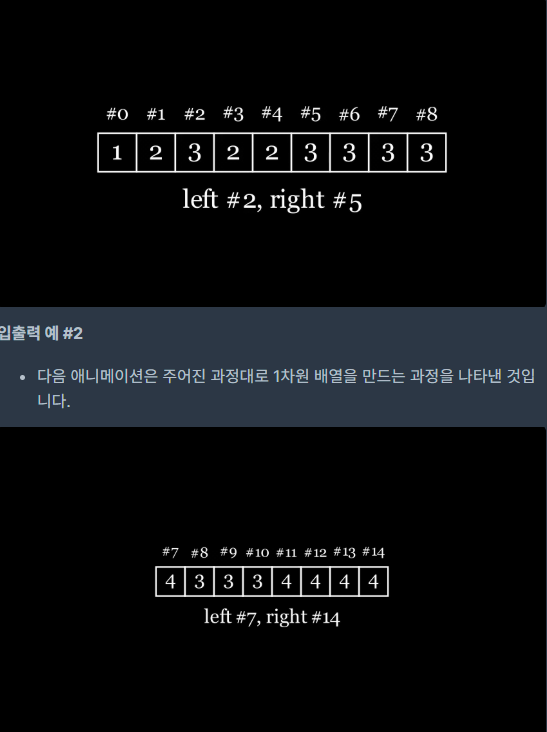

1) 내가 쓴 코드(시간초과)

In [ ]:
def solution(n, left, right):
    arr = []
    for i in range(1, n+1):
      for _ in range(i):
        arr.append(i)
      if i+1 <= n+1:
        for k in range(i+1, n+1):
          arr.append(k)
    return arr[left:right+1]

In [ ]:
solution(3, 2, 5)

[3, 2, 2, 3]

2) gpt 개선 코드(시간초과)

In [ ]:
def solution(n, left, right):
    arr = []  # 결과를 저장할 리스트

    for i in range(n):  # i는 행 인덱스 (0부터 n-1)
        for j in range(n):  # j는 열 인덱스 (0부터 n-1)
            index = i * n + j  # 1차원 배열에서 현재 (i, j)의 인덱스
            if left <= index <= right:  # left~right 범위 안에 있는 경우만 추가
                arr.append(max(i, j) + 1)  # 값은 max(i, j) + 1

    return arr  # left ~ right 범위의 값만 반환

# 테스트 실행
print(solution(3, 2, 5))  # [3,2,2,3]
print(solution(4, 7, 14))  # [4,3,3,3,4,4,4,4]

[3, 2, 2, 3]
[4, 3, 3, 3, 4, 4, 4, 4]


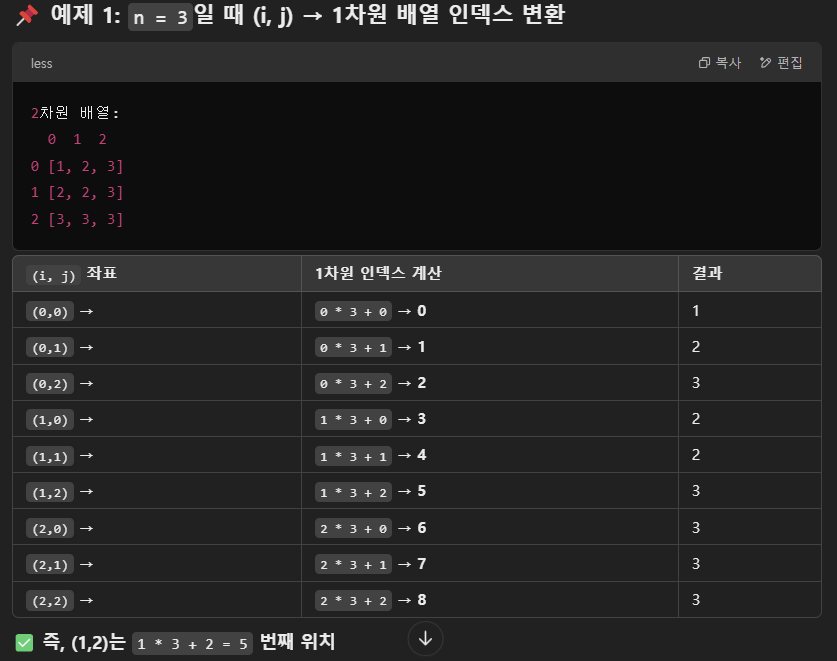

3) 최적화 코드

In [ ]:
def solution(n, left, right):
    return [max(i // n, i % n) + 1 for i in range(left, right + 1)]

✅ 📌 최적 코드 설명
1. i // n과 i % n을 활용
 - 1차원 배열의 인덱스 i 에 대해:
 -- i // n → 몇 번째 행인지 계산
 -- i % n → 몇 번째 열인지 계산
 - 배열에서 (i, j)의 값은 max(i, j) + 1 이므로 :
max(i // n, i % n) + 1
를 사용해 바로 값을 계산합니다.

2. 리스트 없이 left ~ right만 계산
 - range(left, right+1) 만큼만 반복해서 값을 계산
 - 메모리 O(1) 사용 → 매우 효율적

# **74. 폰켓몬(250227)**

In [ ]:
# 문제 설명
# 당신은 폰켓몬을 잡기 위한 오랜 여행 끝에, 홍 박사님의 연구실에 도착했습니다.
# 홍 박사님은 당신에게 자신의 연구실에 있는 총 N 마리의 폰켓몬 중에서 N/2마리를 가져가도 좋다고 했습니다.
# 홍 박사님 연구실의 폰켓몬은 종류에 따라 번호를 붙여 구분합니다. 따라서 같은 종류의 폰켓몬은 같은 번호를 가지고 있습니다.
# 예를 들어 연구실에 총 4마리의 폰켓몬이 있고, 각 폰켓몬의 종류 번호가 [3번, 1번, 2번, 3번]이라면
# 이는 3번 폰켓몬 두 마리, 1번 폰켓몬 한 마리, 2번 폰켓몬 한 마리가 있음을 나타냅니다.
# 이때, 4마리의 폰켓몬 중 2마리를 고르는 방법은 다음과 같이 6가지가 있습니다.

# 첫 번째(3번), 두 번째(1번) 폰켓몬을 선택
# 첫 번째(3번), 세 번째(2번) 폰켓몬을 선택
# 첫 번째(3번), 네 번째(3번) 폰켓몬을 선택
# 두 번째(1번), 세 번째(2번) 폰켓몬을 선택
# 두 번째(1번), 네 번째(3번) 폰켓몬을 선택
# 세 번째(2번), 네 번째(3번) 폰켓몬을 선택

# 이때, 첫 번째(3번) 폰켓몬과 네 번째(3번) 폰켓몬을 선택하는 방법은 한 종류(3번 폰켓몬 두 마리)의 폰켓몬만 가질 수 있지만,
# 다른 방법들은 모두 두 종류의 폰켓몬을 가질 수 있습니다. 따라서 위 예시에서 가질 수 있는 폰켓몬 종류 수의 최댓값은 2가 됩니다.
# 당신은 최대한 다양한 종류의 폰켓몬을 가지길 원하기 때문에, 최대한 많은 종류의 폰켓몬을 포함해서 N/2마리를 선택하려 합니다.
# N마리 폰켓몬의 종류 번호가 담긴 배열 nums가 매개변수로 주어질 때, N/2마리의 폰켓몬을 선택하는 방법 중,
# 가장 많은 종류의 폰켓몬을 선택하는 방법을 찾아, 그때의 폰켓몬 종류 번호의 개수를 return 하도록 solution 함수를 완성해주세요.

# 제한사항
# nums는 폰켓몬의 종류 번호가 담긴 1차원 배열입니다.
# nums의 길이(N)는 1 이상 10,000 이하의 자연수이며, 항상 짝수로 주어집니다.
# 폰켓몬의 종류 번호는 1 이상 200,000 이하의 자연수로 나타냅니다.
# 가장 많은 종류의 폰켓몬을 선택하는 방법이 여러 가지인 경우에도, 선택할 수 있는 폰켓몬 종류 개수의 최댓값 하나만 return 하면 됩니다.

# 입출력 예
# nums	result
# [3,1,2,3]	2
# [3,3,3,2,2,4]	3
# [3,3,3,2,2,2]	2

# 입출력 예 설명

# 입출력 예 #1
# 문제의 예시와 같습니다.

# 입출력 예 #2
# 6마리의 폰켓몬이 있으므로, 3마리의 폰켓몬을 골라야 합니다.
# 가장 많은 종류의 폰켓몬을 고르기 위해서는 3번 폰켓몬 한 마리, 2번 폰켓몬 한 마리, 4번 폰켓몬 한 마리를 고르면 되며, 따라서 3을 return 합니다.

# 입출력 예 #3
# 6마리의 폰켓몬이 있으므로, 3마리의 폰켓몬을 골라야 합니다.
# 가장 많은 종류의 폰켓몬을 고르기 위해서는 3번 폰켓몬 한 마리와 2번 폰켓몬 두 마리를 고르거나,
# 혹은 3번 폰켓몬 두 마리와 2번 폰켓몬 한 마리를 고르면 됩니다. 따라서 최대 고를 수 있는 폰켓몬 종류의 수는 2입니다.

1) 내 코드

In [ ]:
def solution(nums):
    return len(set(nums)) if len(set(nums)) <= len(nums)/2 else len(nums)/2

In [ ]:
nums = [3,3,3,2,2,2]

In [ ]:
solution(nums)

2

2) 다른 사람의 코드

In [ ]:
def solution(ls):
    return min(len(ls)/2, len(set(ls)))

# **75. 행렬의 곱셈(250303)**

In [ ]:
# 문제 설명
# 2차원 행렬 arr1과 arr2를 입력받아, arr1에 arr2를 곱한 결과를 반환하는 함수, solution을 완성해주세요.

# 제한 조건
# 행렬 arr1, arr2의 행과 열의 길이는 2 이상 100 이하입니다.
# 행렬 arr1, arr2의 원소는 -10 이상 20 이하인 자연수입니다.
# 곱할 수 있는 배열만 주어집니다.
# 입출력 예
# arr1	arr2	return
# [[1, 4], [3, 2], [4, 1]]	[[3, 3], [3, 3]]	[[15, 15], [15, 15], [15, 15]]
# [[2, 3, 2], [4, 2, 4], [3, 1, 4]]	[[5, 4, 3], [2, 4, 1], [3, 1, 1]]	[[22, 22, 11], [36, 28, 18], [29, 20, 14]]

1) 내가 쓴 코드(런타임 초과 에러)

In [57]:
def solution(arr1, arr2):
    answer = []
    for i in range(len(arr1)):
      el = []
      for j in range(len(arr1[i])):
        sum = 0
        for k in range(len(arr2[j])):
          sum += arr1[i][k] * arr2[k][j]
        el.append(sum)
      answer.append(el)
    return answer

In [58]:
arr1 = [[2, 3, 2], [4, 2, 4], [3, 1, 4]]

In [59]:
arr2 = [[5, 4, 3], [2, 4, 1], [3, 1, 1]]

In [60]:
solution(arr1, arr2)

[[22, 22, 11], [36, 28, 18], [29, 20, 14]]

2) gpt 코드 개선

In [ ]:
def solution(arr1, arr2):
    answer = []
    for i in range(len(arr1)):
        row = []
        for j in range(len(arr2[0])):  # arr2의 열 개수를 기준으로 반복
            total = 0
            for k in range(len(arr2)):  # arr1의 열 개수 == arr2의 행 개수
                total += arr1[i][k] * arr2[k][j]
            row.append(total)
        answer.append(row)
    return answer

3) 최적 코드

In [ ]:
import numpy as np  # NumPy 라이브러리 불러오기 (행렬 연산 최적화)

def solution(arr1, arr2):
    return np.dot(arr1, arr2).tolist()  # NumPy의 dot()을 이용해 행렬 곱셈 수행 후 리스트로 변환

🔹 코드 설명
1) import numpy as np
 - NumPy: 수치 연산을 빠르게 처리할 수 있는 파이썬 라이브러리
 -- 행렬 연산, 선형 대수, 통계 등 다양한 기능 제공
 -- 내부적으로 C로 구현되어 있어 매우 빠름
 - np는 NumPy의 약칭(alias) 으로, 이후 코드에서 np.dot() 처럼 활용됨.

2) np.dot(arr1, arr2)
 - np.dot(A, B): 두 행렬 A와 B의 곱을 계산하는 함수
 - 행렬 곱셈을 수행하며, 행렬의 크기가 m × n, n × p이면 결과는 m × p 크기가 됨.
 - 내부적으로 최적화된 연산을 사용하여 반복문보다 훨씬 빠르게 동작.

3) .tolist()
 - NumPy 배열(numpy.ndarray)은 기본적으로 리스트와 비슷하지만,
리스트가 아니므로 .tolist()를 사용해 파이썬 기본 리스트로 변환.

4) 다른 사람의 코드

In [ ]:
def productMatrix(A, B):
    return [[sum(a*b for a, b in zip(A_row,B_col)) for B_col in zip(*B)] for A_row in A]

In [ ]:
def productMatrix(A, B):
    return [
        [sum(a * b for a, b in zip(A_row, B_col))  # A의 행과 B의 열을 곱해서 합산
         for B_col in zip(*B)]  # B의 열을 행처럼 변환한 후 순회
        for A_row in A  # A의 각 행을 순회
    ]

🔹 코드 설명

이 코드는 리스트 내포(list comprehension) + zip()을 활용한 행렬 곱셈 구현 방식이다.

1) zip(*B): 행렬 B의 전치(transpose)
 - zip(*B)는 B의 열을 행처럼 다룰 수 있도록 변환하는 역할을 함.
 - 원래 B의 구조가 이렇게 생겼다면

In [ ]:
B = [[1, 2, 3],
     [4, 5, 6]]

In [ ]:
[(1, 4), (2, 5), (3, 6)]  # B의 열이 행으로 변환됨

즉, 원래 행렬 B의 열(column) 을 zip()을 이용해 행(row)처럼 사용.

2) for A_row in A: A의 행을 하나씩 가져옴
 - A_row는 행렬 A에서 한 행씩 가져오는 역할을 함.

3) for B_col in zip(*B): B의 열을 한 행처럼 가져옴
 - B_col은 zip(*B)로 변환된 B의 열을 나타냄.

4) sum(a * b for a, b in zip(A_row, B_col))
 - zip(A_row, B_col): A_row의 원소들과 B_col의 원소들을 쌍(pair) 으로 묶음.
 - a * b: 두 원소를 곱함.
 - sum(...): 각각 곱한 값을 모두 더해서 스칼라 값을 계산.